In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

shrna_in = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Mastersheet_Input/Log2FC_TTR_shRNAone_1nt_260702_3reps.csv"
psp_in = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Mastersheet_Input/Log2FC_TTR_PspCas13b_1nt.csv"
u1_in = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Mastersheet_Input/Log2FC_TTR_RfxCas13d_U1-crRNA_1nt.csv"

shrna_df = pd.read_csv(shrna_in)
psp_df = pd.read_csv(psp_in)
u1_df = pd.read_csv(u1_in)

shrna_df["start_nt_NM_000371.3"] = pd.to_numeric(shrna_df["start_nt_NM_000371.3"], errors="coerce")
psp_df["start_nt_NM_000371.3"] = pd.to_numeric(psp_df["start_nt_NM_000371.3"], errors="coerce")
u1_df["start_nt_NM_000371.3"] = pd.to_numeric(u1_df["start_nt_NM_000371.3"], errors="coerce")

shrna_df = shrna_df[(shrna_df["start_nt_NM_000371.3"] >= 111) & (shrna_df["start_nt_NM_000371.3"] <= 709)].copy()
psp_df = psp_df[(psp_df["start_nt_NM_000371.3"] >= 111) & (psp_df["start_nt_NM_000371.3"] <= 697)].copy()
u1_df = u1_df[(u1_df["start_nt_NM_000371.3"] >= 111) & (u1_df["start_nt_NM_000371.3"] <= 704)].copy()

output_dir = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Figure5_Graph/Reviewed_Figure5/260724_Reviewed_Final"
os.makedirs(output_dir, exist_ok=True)

In [2]:
# Prep shRNA: Log2FC_mean vs start_nt
d_shrna = shrna_df[["start_nt_NM_000371.3", "Log2FC_mean"]].copy()
d_shrna["start_nt_NM_000371.3"] = pd.to_numeric(d_shrna["start_nt_NM_000371.3"], errors="coerce")
d_shrna["Log2FC_mean"] = pd.to_numeric(d_shrna["Log2FC_mean"], errors="coerce")
d_shrna = d_shrna.dropna(subset=["start_nt_NM_000371.3", "Log2FC_mean"]).sort_values("start_nt_NM_000371.3")

# U1: use rep3_day5_Log2FC
u1_log2fc_col = "rep3_day5_Log2FC"
d_u1 = u1_df[["start_nt_NM_000371.3", u1_log2fc_col]].copy()
d_u1["start_nt_NM_000371.3"] = pd.to_numeric(d_u1["start_nt_NM_000371.3"], errors="coerce")
d_u1[u1_log2fc_col] = pd.to_numeric(d_u1[u1_log2fc_col], errors="coerce")
d_u1 = d_u1.dropna(subset=["start_nt_NM_000371.3", u1_log2fc_col]).sort_values("start_nt_NM_000371.3")

In [5]:
offset_range = list(range(-10, 31))

results = []
best_corr = -float("inf")
best_offset = None

u1_col_name = "rep3_day5_Log2FC"         
shrna_col_name = "Log2FC_mean"

for offset in offset_range:
    d_u1_tmp = d_u1.copy()
    d_u1_tmp["start_nt_NM_000371.3"] = d_u1_tmp["start_nt_NM_000371.3"] + offset

    # Merge on shifted CasRx coordinates vs fixed shRNA
    shared = pd.merge(
        d_u1_tmp, d_shrna,
        on="start_nt_NM_000371.3",
        suffixes=["_U1", "_shrna"]
    )

    if offset == 0:
        print("d_u1 columns:", d_u1.columns.tolist())
        print("merged columns:", shared.columns.tolist())
        print("u1_col_name:", u1_col_name, "present?", u1_col_name in shared.columns)
        print("shrna_col_name:", shrna_col_name, "present?", shrna_col_name in shared.columns)

    if shared.empty or shared[u1_col_name].nunique() < 2 or shared[shrna_col_name].nunique() < 2:
        corr = float("nan")
    else:
        corr = shared[u1_col_name].corr(shared[shrna_col_name], method="pearson")

    if corr > best_corr and not pd.isna(corr):
        best_corr = corr
        best_offset = offset

    results.append({
        "offset": offset,
        "pearson_correlation": corr,
        "n_shared_positions": len(shared)
    })

results_df = pd.DataFrame(results)

print("Best offset (CasRx shifted):", best_offset, "with Pearson r:", best_corr)

d_u1 columns: ['start_nt_NM_000371.3', 'rep3_day5_Log2FC']
merged columns: ['start_nt_NM_000371.3', 'rep3_day5_Log2FC', 'Log2FC_mean']
u1_col_name: rep3_day5_Log2FC present? True
shrna_col_name: Log2FC_mean present? True
Best offset (CasRx shifted): 1 with Pearson r: 0.38917566960231853


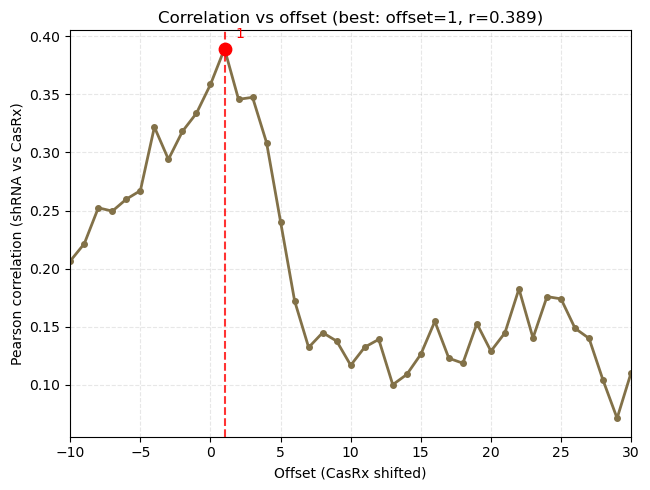

In [6]:
# Plot correlation vs offset without data point labels
fig, ax = plt.subplots(figsize=(6.6, 5))

offsets = results_df["offset"]
corrs = results_df["pearson_correlation"]

# Line
ax.plot(offsets, corrs, color="#827148", linewidth=2, marker="o", markersize=4)

# Highlight best offset only
if best_offset is not None:
    best_row = results_df[results_df["offset"] == best_offset].iloc[0]

    # Red dot at highest correlation
    ax.scatter(
        [best_row["offset"]],
        [best_row["pearson_correlation"]],
        color="red",
        s=80,
        zorder=5
    )

    # Red dotted vertical line at best offset
    ax.axvline(
        best_offset,
        color="red",
        linestyle="--",   # dotted/dashed; use ":" for more dotted
        linewidth=1.5,
        alpha=0.8,
        zorder=3
    )

    # Annotation near the highest correlation point
    ax.annotate(
        f"{int(best_offset)}",
        xy=(best_row["offset"], best_row["pearson_correlation"]),
        xytext=(8, 8),
        textcoords="offset points",
        color="red",
        fontsize=10
    )

ax.set_xlabel("Offset (CasRx shifted)")
ax.set_ylabel("Pearson correlation (shRNA vs CasRx)")
ax.set_title(f"Correlation vs offset (best: offset={best_offset}, r={best_corr:.3f})")
ax.grid(True, linestyle="--", alpha=0.3)
ax.margins(x=0)

plt.tight_layout()

# pdf_path = os.path.join(output_dir, "260724_datapoint_offset_correlation_CasRx_shRNA.pdf")
# plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()

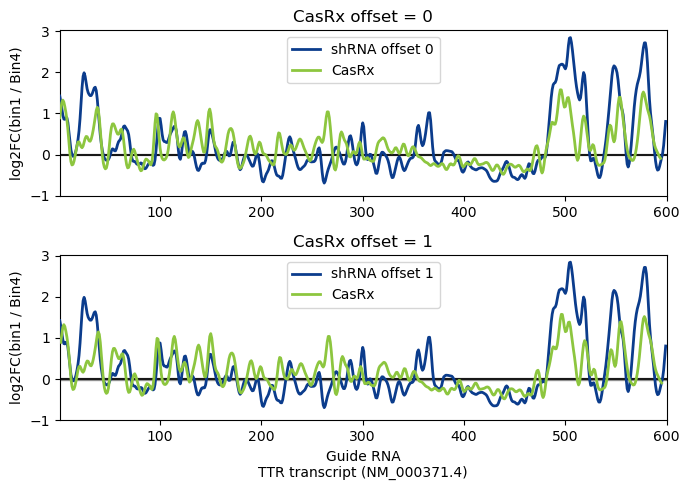

In [3]:
sigma_nt_default = 2
offsets = [0, 1]
fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharey=True)

line_sh = "#0b3c8c"
line_c_casrx = "#8dc63f"

def gaussian_smooth_by_nt(x, y, sigma_nt, truncate=4.0):
    x = np.asarray(x)
    y = np.asarray(y)
    if x.ndim != 1 or y.ndim != 1 or x.size != y.size:
        raise ValueError("x and y must be 1D arrays of the same length")
    dx = np.median(np.diff(x))
    if dx <= 0:
        raise ValueError("x must be strictly increasing")
    sigma_idx = sigma_nt / dx
    y_smooth = gaussian_filter1d(y, sigma=sigma_idx, mode="nearest", truncate=truncate)
    return x, y_smooth

for ax, offset in zip(axes, offsets):
    # shRNA (with offset)
    d_sh = shrna_df[["start_nt_NM_000371.3", "Log2FC_mean"]].copy()
    d_sh["Log2FC_mean"] = pd.to_numeric(d_sh["Log2FC_mean"], errors="coerce")
    d_sh = d_sh.dropna().sort_values("start_nt_NM_000371.3")
    x_sh = d_sh["start_nt_NM_000371.3"].to_numpy() - 110 
    y_sh = d_sh["Log2FC_mean"].to_numpy()

    # CasRx day5 (no offset)
    d_u1 = u1_df[["start_nt_NM_000371.3", "rep3_day5_Log2FC"]].copy()
    d_u1["start_nt_NM_000371.3"] = pd.to_numeric(d_u1["start_nt_NM_000371.3"], errors="coerce")
    d_u1 = d_u1.dropna().sort_values("start_nt_NM_000371.3")
    x_u1 = d_u1["start_nt_NM_000371.3"].to_numpy() - 110 + offset
    y_u1 = d_u1["rep3_day5_Log2FC"].to_numpy()

    # smoothed lines using shared helper
    if len(x_sh) >= 4:
        x_sh_s, y_sh_s = gaussian_smooth_by_nt(x_sh, y_sh, sigma_nt_default)
        ax.plot(x_sh_s, y_sh_s, color=line_sh, linewidth=2,
                zorder=3, label=f"shRNA offset {offset}")

    if len(x_u1) >= 4:
        x_u1_s, y_u1_s = gaussian_smooth_by_nt(x_u1, y_u1, sigma_nt_default)
        ax.plot(x_u1_s, y_u1_s, color=line_c_casrx, linewidth=2,
                zorder=3, label="CasRx")

    # styling
    ax.axhspan(-0.02, 0.02, color="#666666", alpha=0.6, zorder=0)
    ax.axhline(0, color="black", linewidth=1.2, zorder=2)
    ax.margins(x=0)
    ax.set_xticks([100, 200, 300, 400, 500, 600])
    ax.set_yticks([-1, 0, 1, 2, 3])
    ax.set_ylabel("log2FC(bin1 / Bin4)")
    ax.set_title(f"CasRx offset = {offset}")
    ax.legend()

axes[-1].set_xlabel("Guide RNA\nTTR transcript (NM_000371.4)")
# plt.savefig(os.path.join(output_dir,"260724_Figure5_shRNA_CasRx_0_1.pdf"),format="pdf",bbox_inches="tight")
plt.tight_layout()
plt.show()